In [1]:
# Preamble
%load_ext autoreload
# %load_ext memory_profiler
%autoreload 2
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import maglab.formats.mumax3 as mx3
import maglab.analysis.ringdown as rd
import maglab.loaders.ringdown as l_rd
import maglab.loaders.utils as l_ut

In [4]:
TABLE_PATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out") / "table.txt"
table = mx3.read_table(TABLE_PATH)
# table.loc[0, ["mx ()", "my ()", "mz ()"]].to_numpy()
# table.loc[:, table.columns.str.contains("mx|my|mz")]
# table.loc[0, table.columns.str.contains("B_extx|B_exty|B_extz")]
l_ut.compute_dot_vectors(table, ["m", "B_ext"], direction="B_ext")
# table

[array([-1.12721540e-10,  4.52447720e-07,  8.95513100e-07, ...,
        -1.61017460e-08, -1.38172185e-08, -1.07641210e-08], shape=(1201,)),
 array([ 8.3346096e-22,  7.8623110e-08, -2.2975273e-09, ...,
         1.8228659e-10,  4.0687160e-09,  2.3830931e-23], shape=(1201,))]

(0.0, 18.0)

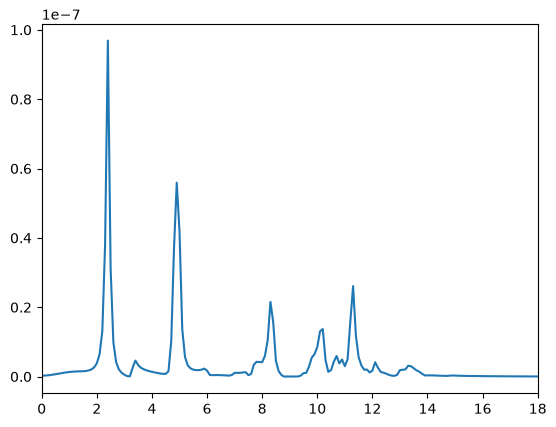

In [4]:
TABLE_PATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out") / "table.txt"

df = l_rd.load_mag_avg_ringdown(TABLE_PATH)
plt.plot(df["frequency"], df["absorption"])
plt.xlim(0, 18)

In [49]:
dfs = []
for i in [10, 20, 30, 40, 60, 80, 150]:
    dirpath = Path(fr"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct_kc{i}.out")
    _, freqs, bls, fmr = l_rd.load_ringdown(dirpath)
    df = pd.DataFrame({"frequency": freqs, f"BLS kc {-i}": bls, f"FMR kc {-i}": fmr})
    dfs.append(df)

Loading OVF files: 100%|██████████| 1201/1201 [00:02<00:00, 569.69 files/s]


Loading OVF files: 100%|██████████| 1201/1201 [00:01<00:00, 1046.06 files/s]


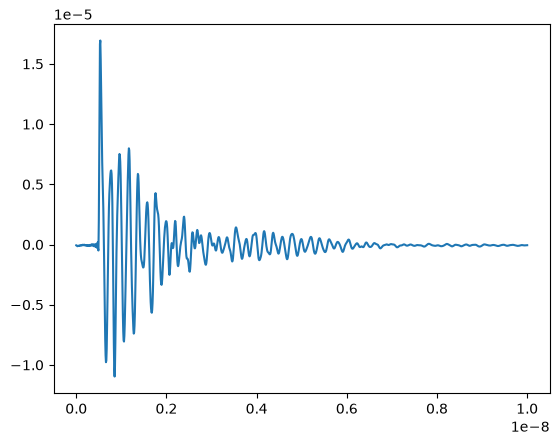

In [72]:
# DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-05-22 AASI Dynamics 2x2\1-1\1-1_phi0_3\1-1_phi0_3exct_B000060.out")
# DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out")
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct_nomask_damp.out")
# (psd, phase), (frequencies, psd_spectrum) = l_rd.load_ringdown(DIRPATH)
# plt.plot(frequencies, psd_spectrum)

spec, freqs, bls, fmr = l_rd.load_ringdown(DIRPATH)

In [ ]:
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct_nomask_damp.out")
absorption, (f, kx, ky) = l_rd.load_dispersion(DIRPATH)

Loading OVF files: 100%|██████████| 1201/1201 [00:00<00:00, 1702.56 files/s]


In [53]:
tot_df = pd.concat(dfs, axis=1)
tot_df = tot_df.loc[:, ~tot_df.columns.duplicated()]
tot_df.to_csv("kc.csv")
# tot_df.loc[:900, :]

Text(0, 0.5, 'BLS intensity (arb. units.)')

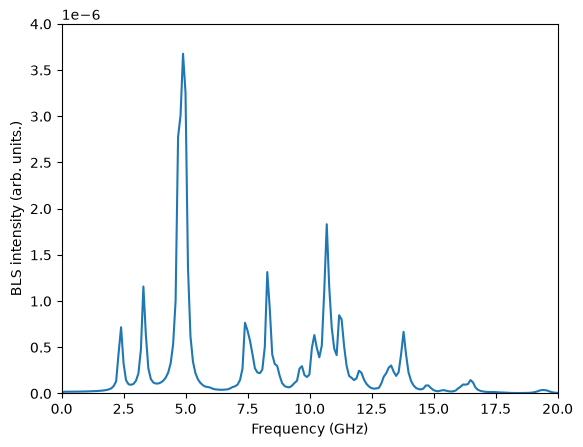

In [75]:
plt.plot(freqs / 1e9, bls)
plt.xlim(0, 20)
# plt.ylim(0, 0.3e-6)
# plt.ylim(0, 0.2e-8)
# plt.ylim(0, 1.2e-6)
# plt.ylim(0, 5e-6)
# plt.ylim(0, 3e-7)
plt.ylim(0, 4e-6)
# plt.ylim(0, 4000e-8)
# plt.ylim(0, 1000e-8)
plt.xlabel("Frequency (GHz)")
plt.ylabel("BLS intensity (arb. units.)")


In [49]:
blss.append(bls)

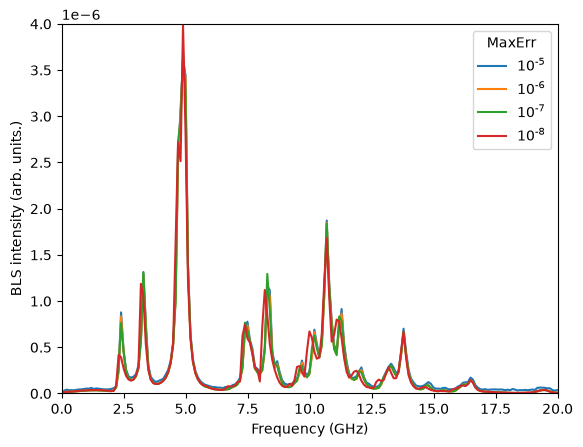

In [51]:
labels = [r"$\text{10}^\text{-5}$", r"$\text{10}^\text{-6}$", r"$\text{10}^\text{-7}$", r"$\text{10}^\text{-8}$"]
for i, b in enumerate(blss):
    plt.plot(freqs / 1e9, b, label = labels[i])
plt.xlim(0, 20)
# plt.ylim(0, 1.2e-6)
plt.ylim(0, 4e-6)
plt.xlabel("Frequency (GHz)")
plt.ylabel("BLS intensity (arb. units.)")
plt.legend(title="MaxErr")

In [ ]:
import pandas as pd
df = pd.DataFrame({"frequency": freqs, -5: blss[0], -6: blss[1], -7: blss[2], -8: blss[3]})


,frequency,-5,-6,-7,-8
0,0.000000e+00,3.744772e-10,4.480344e-10,4.593269e-10,3.409070e-10
1,9.991674e+07,3.040068e-08,1.647327e-08,1.611581e-08,1.606322e-08
2,1.998335e+08,4.126367e-08,1.726781e-08,1.690396e-08,1.703770e-08
3,2.997502e+08,3.640177e-08,1.845320e-08,1.819095e-08,1.826842e-08
4,3.996669e+08,3.656750e-08,2.007266e-08,1.983422e-08,2.008630e-08
...,...,...,...,...,...
596,5.955037e+10,4.011078e-07,4.410792e-09,3.560643e-11,8.882536e-11
597,5.965029e+10,4.271107e-07,6.465083e-09,3.461282e-11,9.034260e-11
598,5.975021e+10,4.311520e-07,4.399629e-09,3.356432e-11,9.632617e-11
599,5.985012e+10,3.459628e-07,3.081498e-09,3.519175e-11,1.017561e-10


In [ ]:
times = [304.0, 300.9, 302.3, 1022.9]
steps = [39729, 39729, 39780, 152939]

In [ ]:
times = [224.9, 198.6, 195.4, 474.7]
steps = [39730, 39727, 39767, 152996]


In [39]:
blss = []

2.398001665278934


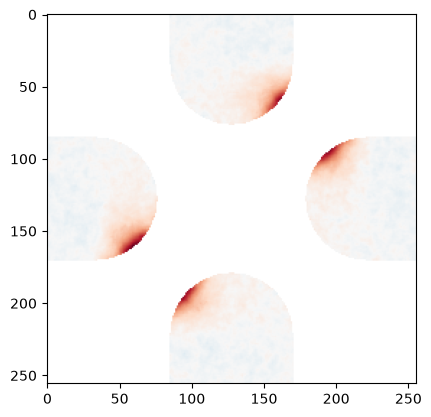

3.297252289758534


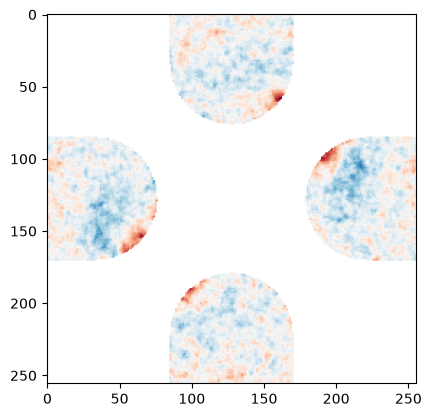

4.296419650291424


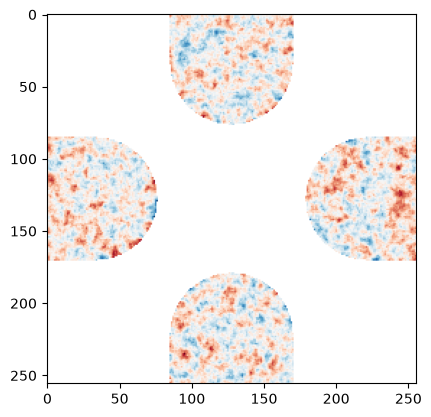

4.895920066611158


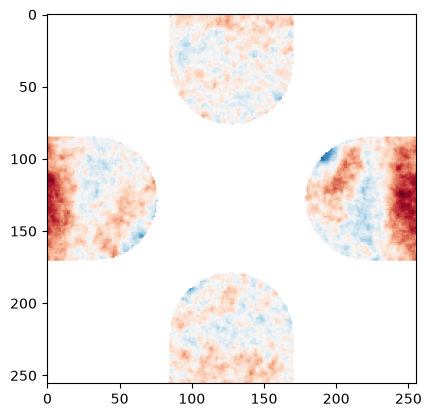

5.395503746877601


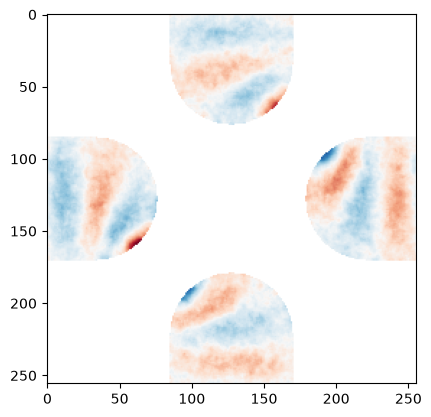

5.995004163197335


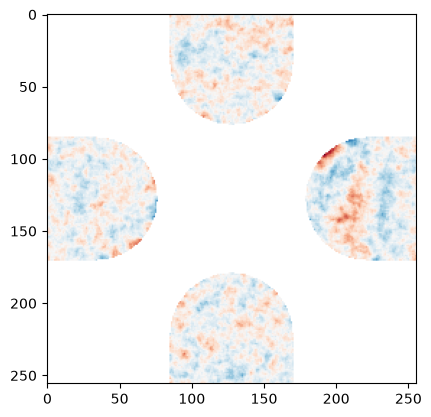

6.49458784346378


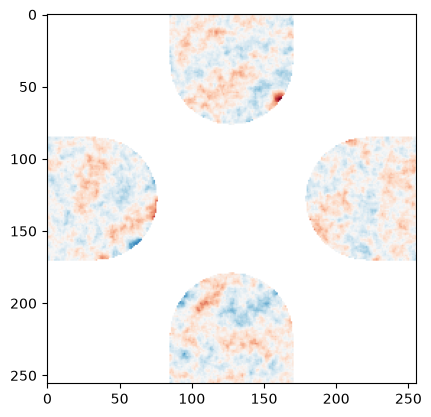

7.194004995836801


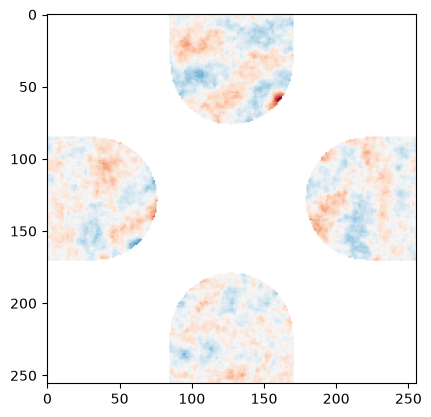

7.493755203996669


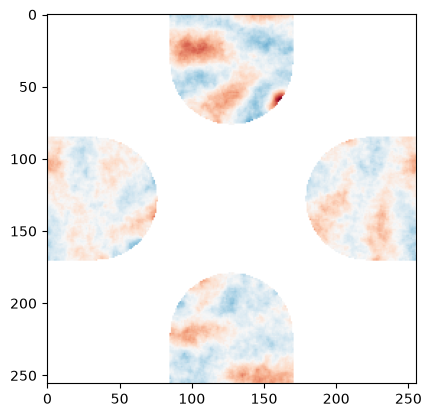

7.893422148209824


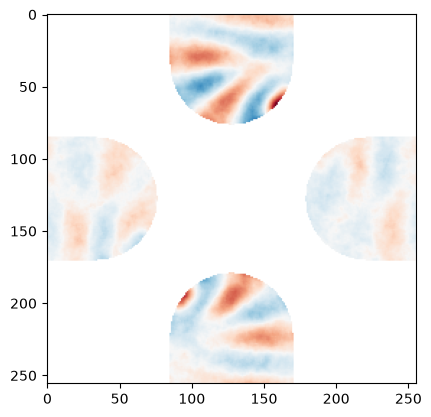

8.39300582847627


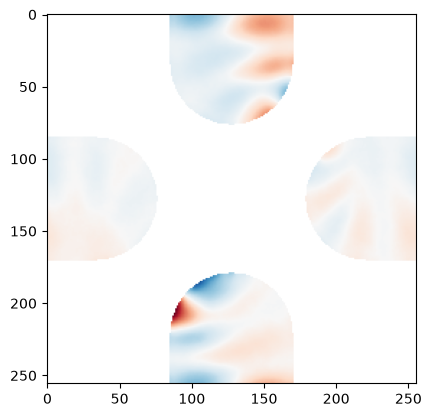

8.692756036636137


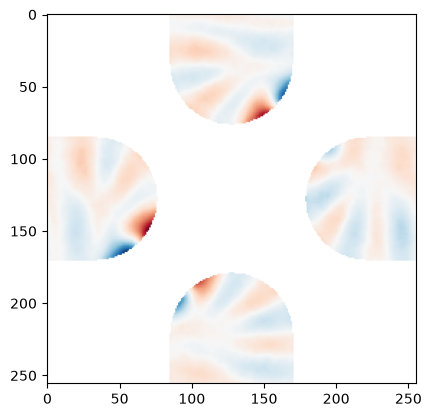

8.992506244796003


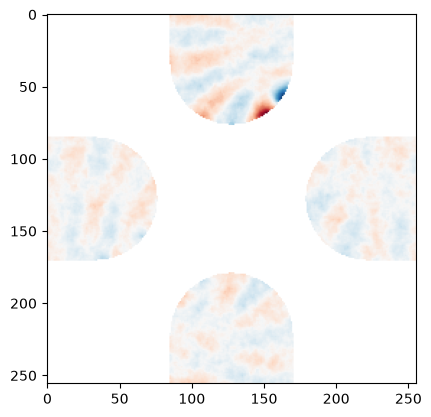

9.392173189009158


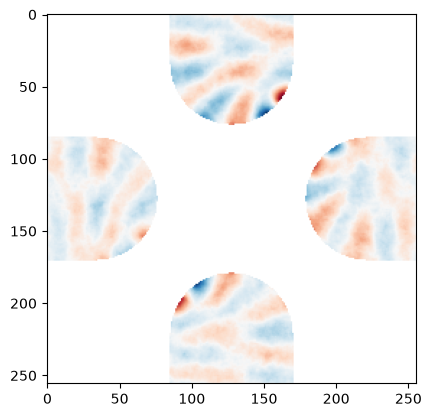

9.691923397169026


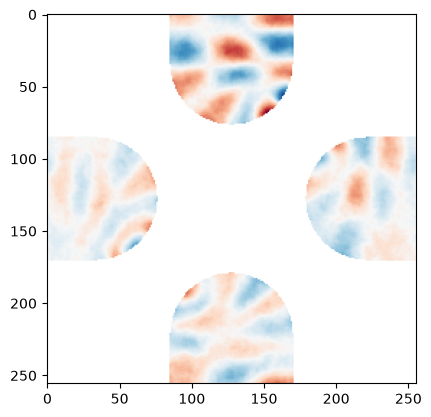

10.591174021648627


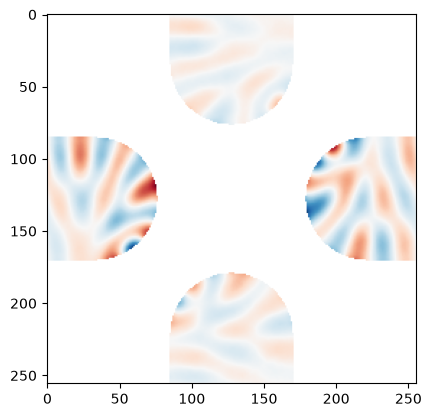

10.990840965861782


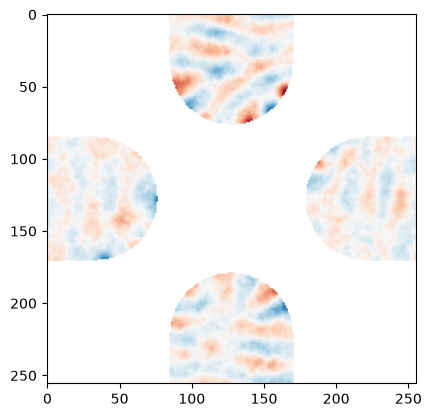

11.190674437968356


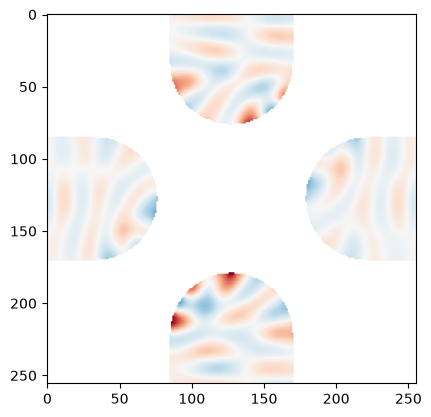

11.590341382181515


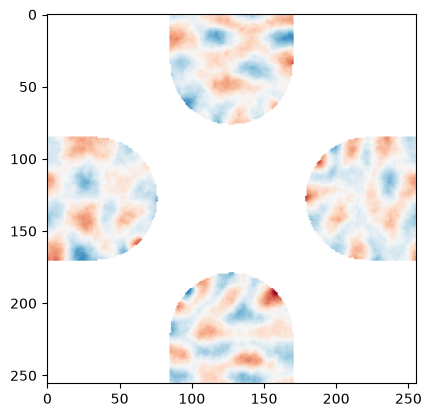

12.389675270607826


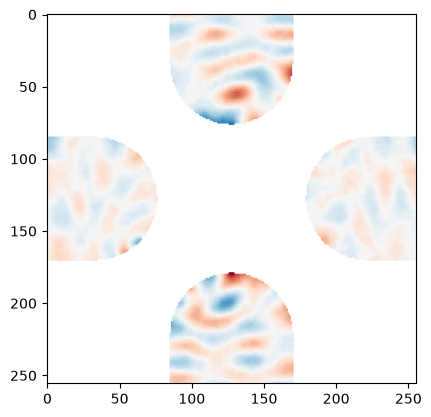

13.288925895087427


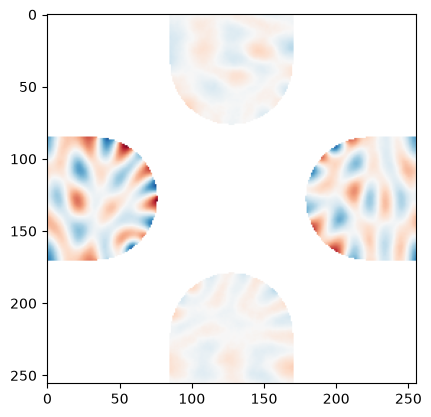

13.988343047460448


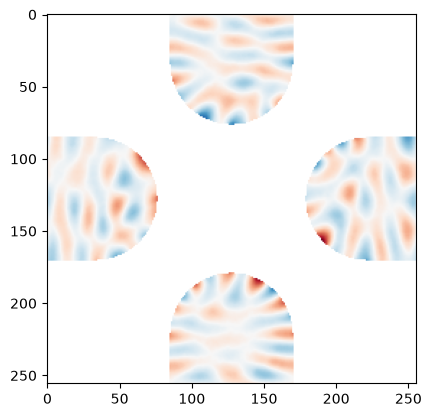

14.787676935886761


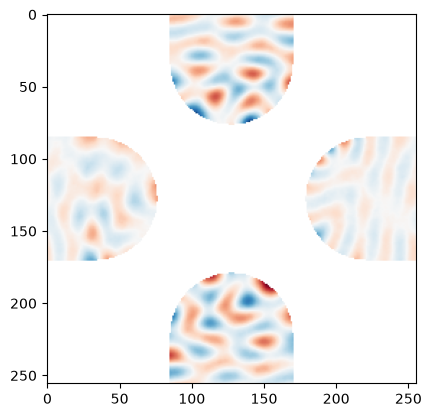

16.086594504579516


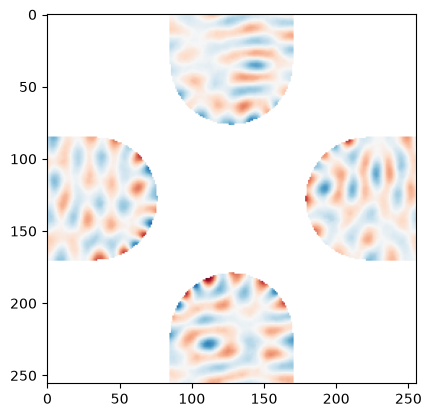

16.985845129059115


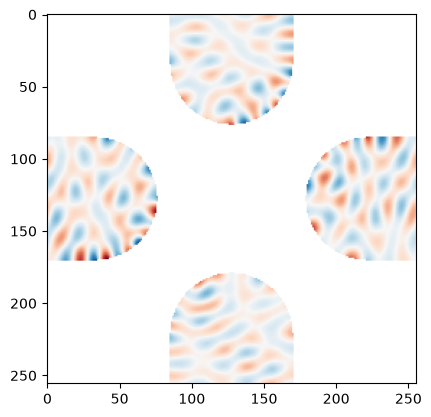

17.285595337218982


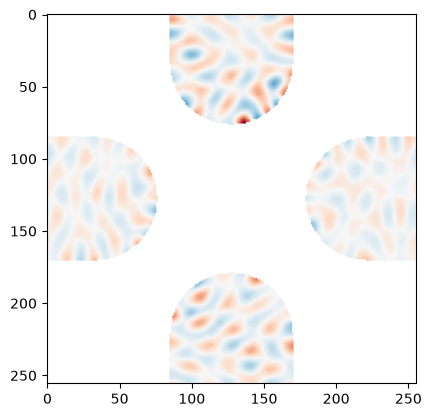

17.78517901748543


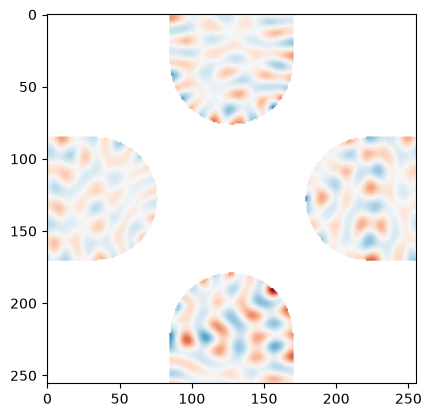

19.38384679433805


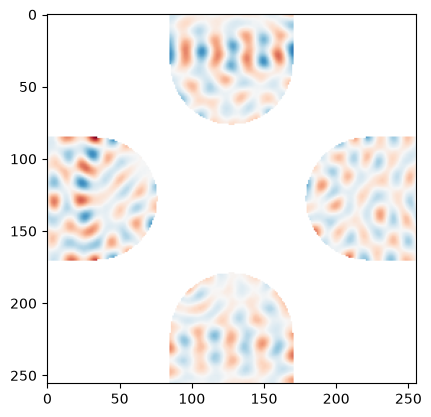

19.883430474604495


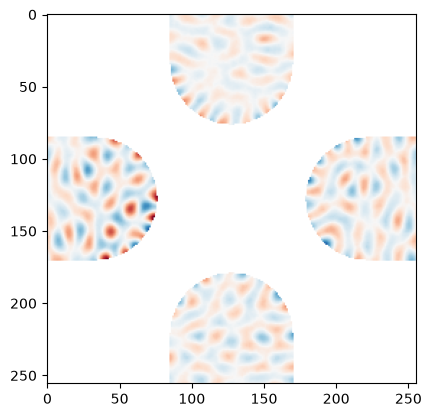

21.08243130724396


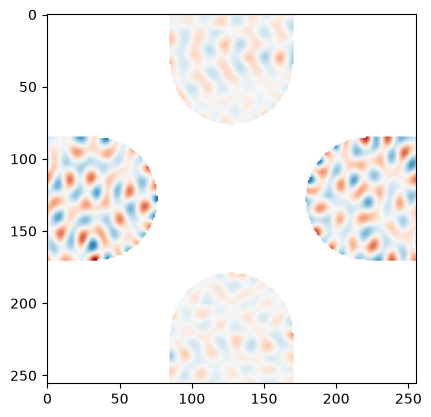

21.881765195670273


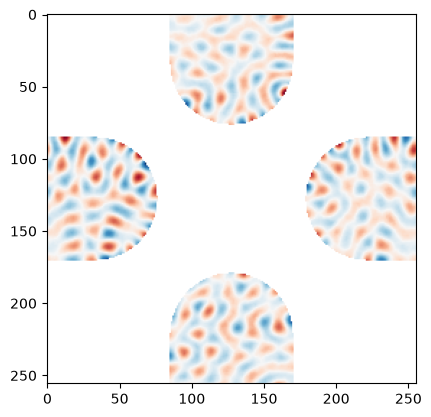

22.781015820149875


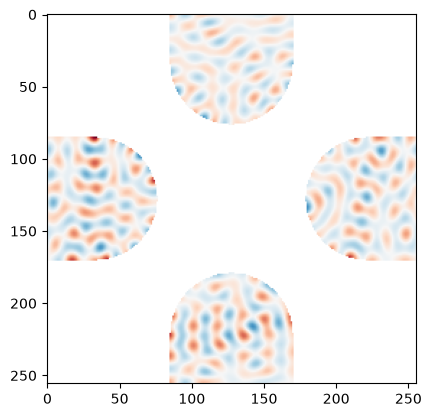

23.780183180682762


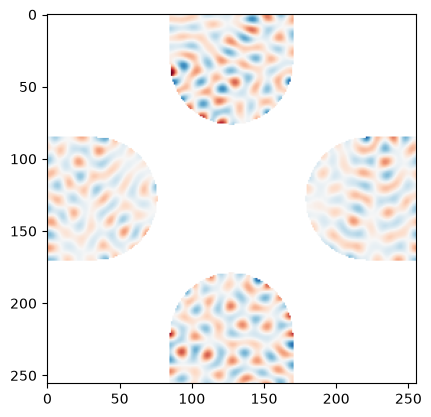

24.979184013322232


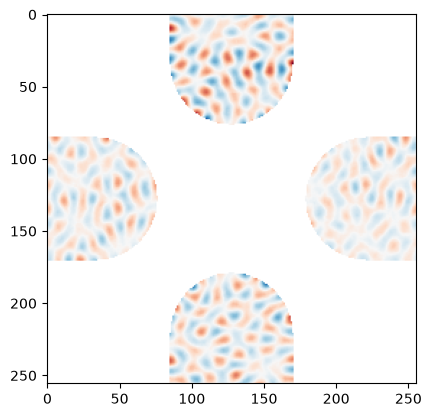

25.87843463780183


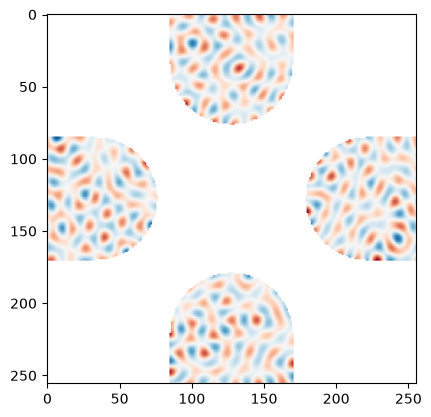

26.278101582014987


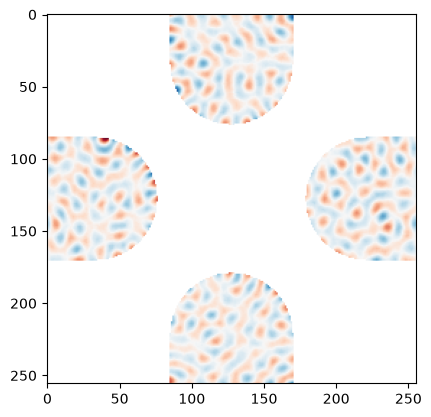

26.877601998334722


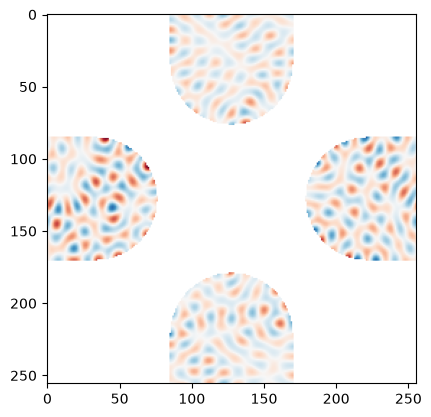

27.477102414654453


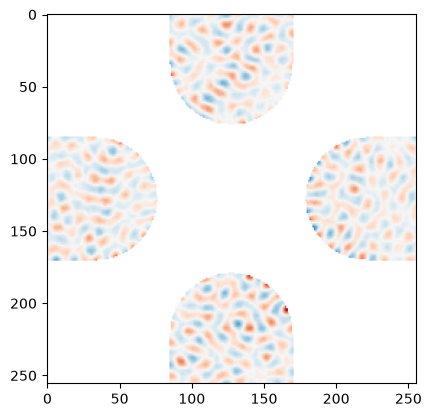

29.075770191507075


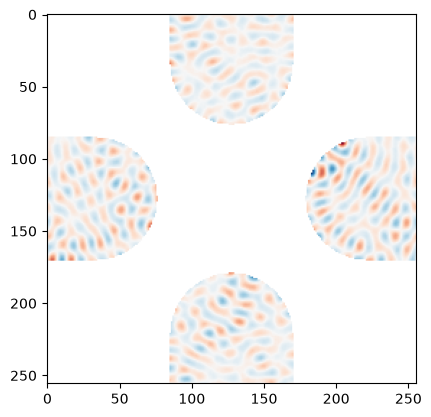

In [61]:
from scipy.signal import find_peaks
peak_idxs, _ = find_peaks(bls[:300])
f_idx = 56
for f_idx in peak_idxs:
    print(freqs[f_idx] / 1e9)
    s = spec[f_idx].mean(axis=0)                    # average over z
    s *= np.exp(-1j*np.angle(s.flat[np.argmax(np.abs(s))]))
    v = np.abs(s.real).max()
    s[s == 0.0] = np.nan
    plt.imshow(s.real, cmap='RdBu_r', vmin=-v, vmax=v)
    # plt.imshow(np.log(s.real), cmap="RdBu_r")
    plt.show()

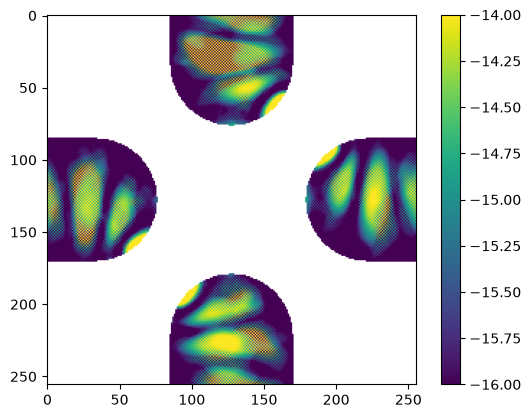

In [40]:
plt.imshow(np.log(psd[46, 4, ...]), clim=(-16, -14))
plt.colorbar()